# Week 6: Regression Analysis & MiniLearn Foundation

## Overview

Two tasks this week:

1. Regression Analysis: Linear Regression applied to predict emotional intensity (normal vs. strong) from Week 5 audio features. Treats the binary label as ordinal (1 = normal, 2 = strong) to identify which acoustic features best predict vocal effort.

2. MiniLearn Foundation: Validates the minilearn preprocessing, metrics, and regression modules against scikit-learn, and previews the LogisticRegression classifier.

### Regression target
| Label | Meaning | Numeric code |
|-------|---------|-------------|
| normal | regular emotional intensity | 1 |
| strong | heightened/intense delivery | 2 |

Neutral speech only appears in normal intensity, creating a slight class imbalance.

## 1. Imports & Setup

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression as SklearnLR, Ridge, Lasso
from sklearn.metrics import mean_squared_error as sk_mse, r2_score as sk_r2
from sklearn.preprocessing import StandardScaler as SklearnScaler

from SER_Project.minilearn.preprocessing import StandardScaler, train_test_split
from SER_Project.minilearn.regression import LinearRegression
from SER_Project.minilearn.metrics import (
    mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
FIGURES_DIR = '../figures'
os.makedirs(FIGURES_DIR, exist_ok=True)
RANDOM_STATE = 42
print('Environment ready.')

## 2. Load Features & Build Regression Target

In [2]:
df = pd.read_csv('../data/features.csv')
print(f'Dataset shape: {df.shape}')
print(f"Columns (first 10): {list(df.columns[:10])}")
print(f"\nIntensity value counts:\n{df['intensity'].value_counts()}")

Dataset shape: (1440, 198)
Columns (first 10): ['filepath', 'emotion', 'emotion_id', 'actor_id', 'gender', 'intensity', 'mfcc_1_mean', 'mfcc_2_mean', 'mfcc_3_mean', 'mfcc_4_mean']

Intensity value counts:
intensity
normal    768
strong    672
Name: count, dtype: int64


In [ ]:
# Encode intensity as numeric: normal=1, strong=2
intensity_map = {'normal': 1, 'strong': 2}
df['intensity_num'] = df['intensity'].map(intensity_map)

# Identify feature columns (everything after the metadata block)
meta_cols = ['filepath', 'emotion', 'emotion_id', 'actor_id', 'gender', 'intensity', 'intensity_num']
feature_cols = [c for c in df.columns if c not in meta_cols]
print(f'Number of audio features: {len(feature_cols)}')

X_raw = df[feature_cols].values
y = df['intensity_num'].values
print(f'X shape: {X_raw.shape} | y shape: {y.shape}')
print(f'y unique values: {np.unique(y)}')

Number of audio features: 192
X shape: (1440, 192) | y shape: (1440,)
y unique values: [1 2]


## 3. Exploratory Analysis of Intensity

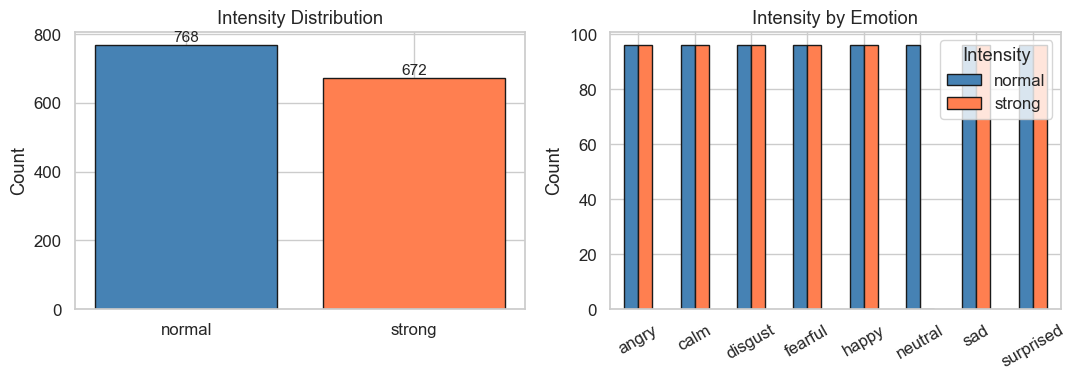

Neutral emotion only appears in "normal" intensity — consistent with RAVDESS design.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Intensity distribution
counts = df['intensity'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue', 'coral'], edgecolor='k')
axes[0].set_title('Intensity Distribution')
axes[0].set_ylabel('Count')
for i, (lbl, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 10, str(cnt), ha='center', fontsize=11)

# Intensity by emotion
intensity_by_emotion = df.groupby(['emotion', 'intensity']).size().unstack(fill_value=0)
intensity_by_emotion.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'],
                           edgecolor='k', rot=30)
axes[1].set_title('Intensity by Emotion')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('')
axes[1].legend(title='Intensity')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/w6_intensity_distribution.png', dpi=120)
plt.show()
print('Neutral emotion only appears in "normal" intensity — consistent with RAVDESS design.')

C:\Users\zacha\OneDrive\Documents\miami\cse432\Project_CSE432-532\.venv\lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\zacha\OneDrive\Documents\miami\cse432\Project_CSE432-532\.venv\lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


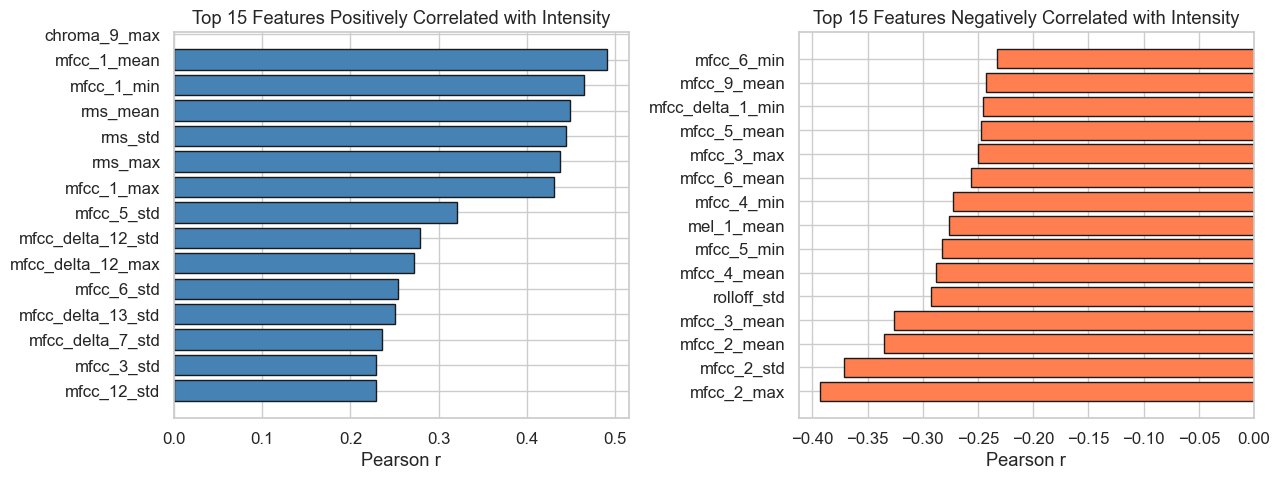

Strongest positive: mfcc_1_mean (0.4910)
Strongest negative: mfcc_2_max (-0.3927)


In [6]:
# Correlation of every feature with the numeric intensity target
correlations = pd.Series(
    [np.corrcoef(df[col], y)[0, 1] for col in feature_cols],
    index=feature_cols
).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Top 15 positive correlations
top_pos = correlations.tail(15)
axes[0].barh(top_pos.index, top_pos.values, color='steelblue', edgecolor='k')
axes[0].set_title('Top 15 Features Positively Correlated with Intensity')
axes[0].set_xlabel('Pearson r')

# Top 15 negative correlations
top_neg = correlations.head(15)
axes[1].barh(top_neg.index, top_neg.values, color='coral', edgecolor='k')
axes[1].set_title('Top 15 Features Negatively Correlated with Intensity')
axes[1].set_xlabel('Pearson r')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/w6_feature_intensity_correlation.png', dpi=120)
plt.show()

print(f'Strongest positive: {correlations.idxmax()} ({correlations.max():.4f})')
print(f'Strongest negative: {correlations.idxmin()} ({correlations.min():.4f})')

## 4. Data Split & Standardisation

The scaler is fitted only on the training set and applied to the test set to prevent data leakage.

In [ ]:
# MiniLearn split & scale
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on TRAIN only
X_test_s  = scaler.transform(X_test)        # apply same params to TEST

print(f'Train size: {X_train_s.shape}   Test size: {X_test_s.shape}')
print(f'Train target distribution: normal={np.sum(y_train==1)}, strong={np.sum(y_train==2)}')
print(f'Test  target distribution: normal={np.sum(y_test==1)},  strong={np.sum(y_test==2)}')

Train size: (1151, 192)   Test size: (289, 192)
Train target distribution: normal=614, strong=537
Test  target distribution: normal=154,  strong=135


## 5. MiniLearn Linear Regression

### 5.1 Normal Equation Solver

The closed-form solution minimises the residual sum of squares directly:

$$\hat{w} = (X^\top X)^{-1} X^\top y$$

We use np.linalg.lstsq internally to handle near-singular matrices gracefully.

In [8]:
# Fit with normal equation
ml_lr_ne = LinearRegression(solver='normal_equation')
ml_lr_ne.fit(X_train_s, y_train)

y_pred_ne_train = ml_lr_ne.predict(X_train_s)
y_pred_ne_test  = ml_lr_ne.predict(X_test_s)

print('=== MiniLearn LinearRegression (Normal Equation) ===')
print(f'  Train  — MSE: {mean_squared_error(y_train, y_pred_ne_train):.4f}  '
      f'RMSE: {root_mean_squared_error(y_train, y_pred_ne_train):.4f}  '
      f'MAE: {mean_absolute_error(y_train, y_pred_ne_train):.4f}  '
      f'R²: {r2_score(y_train, y_pred_ne_train):.4f}')
print(f'  Test   — MSE: {mean_squared_error(y_test, y_pred_ne_test):.4f}  '
      f'RMSE: {root_mean_squared_error(y_test, y_pred_ne_test):.4f}  '
      f'MAE: {mean_absolute_error(y_test, y_pred_ne_test):.4f}  '
      f'R²: {r2_score(y_test, y_pred_ne_test):.4f}')

=== MiniLearn LinearRegression (Normal Equation) ===
  Train  — MSE: 0.1255  RMSE: 0.3542  MAE: 0.2922  R²: 0.4958
  Test   — MSE: 0.1929  RMSE: 0.4393  MAE: 0.3629  R²: 0.2249


### 5.2 Gradient Descent Solver

We also train with batch gradient descent to visualise the loss curve and verify convergence.

=== MiniLearn LinearRegression (Gradient Descent) ===
  Test   — MSE: 0.1890  R²: 0.2406
  Iterations run: 2000


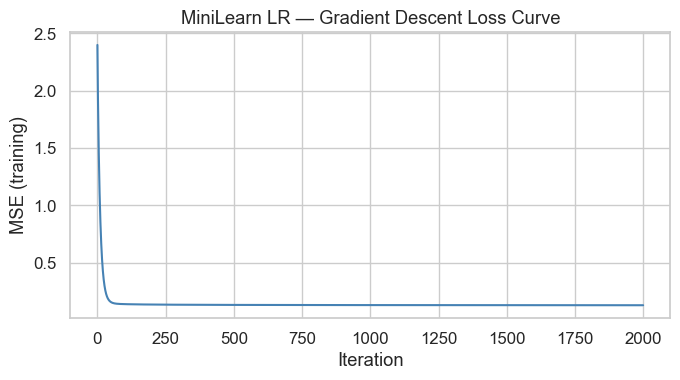

In [9]:
ml_lr_gd = LinearRegression(
    solver='gradient_descent',
    learning_rate=0.05,
    n_iterations=2000
)
ml_lr_gd.fit(X_train_s, y_train)

y_pred_gd_test = ml_lr_gd.predict(X_test_s)

print('=== MiniLearn LinearRegression (Gradient Descent) ===')
print(f'  Test   — MSE: {mean_squared_error(y_test, y_pred_gd_test):.4f}  '
      f'R²: {r2_score(y_test, y_pred_gd_test):.4f}')
print(f'  Iterations run: {len(ml_lr_gd.loss_history_)}')

# Loss curve
plt.figure(figsize=(7, 4))
plt.plot(ml_lr_gd.loss_history_, color='steelblue')
plt.xlabel('Iteration')
plt.ylabel('MSE (training)')
plt.title('MiniLearn LR — Gradient Descent Loss Curve')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/w6_gd_loss_curve.png', dpi=120)
plt.show()

## 6. Scikit-learn Comparison

In [10]:
# Sklearn uses the same scaled train/test data (computed identically, verified below)
sk_scaler = SklearnScaler()
sk_X_train = sk_scaler.fit_transform(X_train)
sk_X_test  = sk_scaler.transform(X_test)

# Quick sanity check: our scaler vs sklearn
max_diff = np.max(np.abs(X_train_s - sk_X_train))
print(f'Max absolute diff between MiniLearn and sklearn scaler: {max_diff:.2e} (should be ~0)')

models_sk = {
    'sklearn LinearRegression': SklearnLR(),
    'sklearn Ridge(α=1)':        Ridge(alpha=1.0),
    'sklearn Lasso(α=0.01)':      Lasso(alpha=0.01, max_iter=5000),
}

results = []

# Add MiniLearn results
for name, y_pred in [
    ('MiniLearn LR (Normal Eq)', y_pred_ne_test),
    ('MiniLearn LR (Grad Desc)', y_pred_gd_test),
]:
    results.append({
        'Model': name,
        'MSE':  round(mean_squared_error(y_test, y_pred), 5),
        'RMSE': round(root_mean_squared_error(y_test, y_pred), 5),
        'MAE':  round(mean_absolute_error(y_test, y_pred), 5),
        'R²':   round(r2_score(y_test, y_pred), 5),
    })

# Fit sklearn models
for name, model in models_sk.items():
    model.fit(sk_X_train, y_train)
    y_pred = model.predict(sk_X_test)
    results.append({
        'Model': name,
        'MSE':  round(sk_mse(y_test, y_pred), 5),
        'RMSE': round(np.sqrt(sk_mse(y_test, y_pred)), 5),
        'MAE':  round(np.mean(np.abs(y_test - y_pred)), 5),
        'R²':   round(sk_r2(y_test, y_pred), 5),
    })

results_df = pd.DataFrame(results)
print('\n=== Regression Model Comparison (Test Set) ===')
display(results_df.set_index('Model').style.highlight_min(subset=['MSE','RMSE','MAE'], color='#d4edda')
                                           .highlight_max(subset=['R²'], color='#d4edda'))

Max absolute diff between MiniLearn and sklearn scaler: 0.00e+00 (should be ~0)

=== Regression Model Comparison (Test Set) ===


,MSE,RMSE,MAE,R²
Model,,,,
MiniLearn LR (Normal Eq),0.192950,0.439260,0.362940,0.224860
MiniLearn LR (Grad Desc),0.189030,0.434770,0.359400,0.240610
sklearn LinearRegression,0.192950,0.439260,0.362940,0.224860
sklearn Ridge(α=1),0.191220,0.437290,0.361160,0.231790
sklearn Lasso(α=0.01),0.174340,0.417540,0.358540,0.299610


## 7. Predicted vs. Actual Plot

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
y_pred = y_pred_ne_test

ax.scatter(y_test, y_pred, alpha=0.35, edgecolors='k', linewidths=0.3, s=40)
lims = [min(y_test.min(), y_pred.min()) - 0.1, max(y_test.max(), y_pred.max()) + 0.1]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
ax.set_xlabel('Actual Intensity')
ax.set_ylabel('Predicted Intensity')
ax.set_title(f'MiniLearn LR (Normal Equation)  R²={r2_score(y_test, y_pred):.4f}')
ax.set_xticks([1, 2])
ax.set_xticklabels(['normal (1)', 'strong (2)'])
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/w6_pred_vs_actual.png', dpi=120)
plt.show()

## 8. Feature Coefficient Analysis

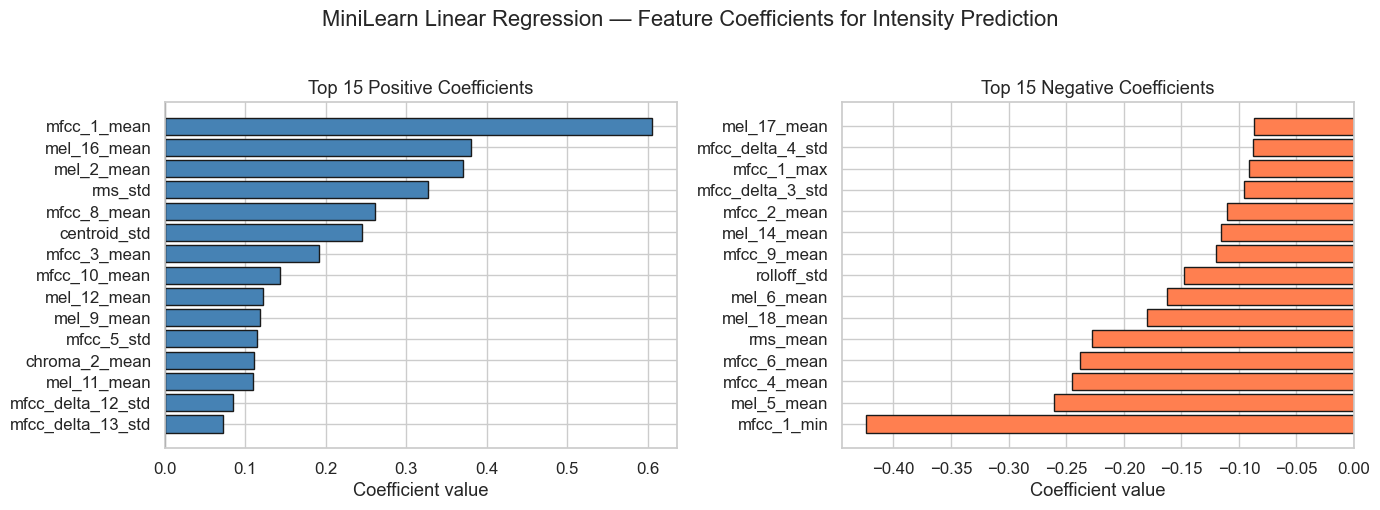

In [12]:
coef_series = pd.Series(ml_lr_ne.coef_, index=feature_cols).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 15 positive (intensity increases as feature increases)
top_pos = coef_series.tail(15)
axes[0].barh(top_pos.index, top_pos.values, color='steelblue', edgecolor='k')
axes[0].set_title('Top 15 Positive Coefficients')
axes[0].set_xlabel('Coefficient value')
axes[0].axvline(0, color='k', linewidth=0.8)

# Top 15 negative
top_neg = coef_series.head(15)
axes[1].barh(top_neg.index, top_neg.values, color='coral', edgecolor='k')
axes[1].set_title('Top 15 Negative Coefficients')
axes[1].set_xlabel('Coefficient value')
axes[1].axvline(0, color='k', linewidth=0.8)

plt.suptitle('MiniLearn Linear Regression — Feature Coefficients for Intensity Prediction', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/w6_coefficients.png', dpi=120)
plt.show()

## 9. Residual Analysis

In [ ]:
residuals = y_test - y_pred_ne_test

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(residuals, bins=30, color='steelblue', edgecolor='k')
axes[0].axvline(0, color='r', linestyle='--')
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residual (actual - predicted)')
axes[0].set_ylabel('Count')

axes[1].scatter(y_pred_ne_test, residuals, alpha=0.35, edgecolors='k', linewidths=0.3, s=30)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/w6_residuals.png', dpi=120)
plt.show()

## 10. MiniLearn Library Validation

In [14]:
from sklearn.metrics import mean_absolute_error as sk_mae
from SER_Project.minilearn.preprocessing import StandardScaler as MLScaler

print('=== MiniLearn vs sklearn — Metric Validation ===')

checks = [
    ('MSE',  mean_squared_error(y_test, y_pred_ne_test),
             sk_mse(y_test, y_pred_ne_test)),
    ('MAE',  mean_absolute_error(y_test, y_pred_ne_test),
             sk_mae(y_test, y_pred_ne_test)),
    ('R²',   r2_score(y_test, y_pred_ne_test),
             sk_r2(y_test, y_pred_ne_test)),
]

all_ok = True
for name, ml_val, sk_val in checks:
    diff = abs(ml_val - sk_val)
    status = '✓ PASS' if diff < 1e-8 else f'✗ FAIL (diff={diff:.2e})'
    print(f'  {name:5s}  MiniLearn={ml_val:.8f}  sklearn={sk_val:.8f}  {status}')
    if diff >= 1e-8:
        all_ok = False

print(f'\nScaler validation:')
ml_sc = MLScaler().fit(X_train)
sk_sc = SklearnScaler().fit(X_train)
mean_diff = np.max(np.abs(ml_sc.mean_ - sk_sc.mean_))
std_diff  = np.max(np.abs(ml_sc.std_  - sk_sc.scale_))
print(f'  Max mean diff:  {mean_diff:.2e}')
print(f'  Max std  diff:  {std_diff:.2e}')

print(f'\nAll checks passed: {all_ok}')

=== MiniLearn vs sklearn — Metric Validation ===
  MSE    MiniLearn=0.19294850  sklearn=0.19294850  ✓ PASS
  MAE    MiniLearn=0.36294377  sklearn=0.36294377  ✓ PASS
  R²     MiniLearn=0.22485561  sklearn=0.22485561  ✓ PASS

Scaler validation:
  Max mean diff:  0.00e+00
  Max std  diff:  0.00e+00

All checks passed: True


## 11. Logistic Regression Preview (Week 7)

Binary intensity classification using MiniLearn LogisticRegression. Full emotion classification follows in Week 7.

=== Logistic Regression Preview: Binary Intensity Classification ===
  MiniLearn LR — Accuracy: 0.7093  F1 (macro): 0.7064
  Sklearn   LR — Accuracy: 0.7128  F1 (macro): 0.7088


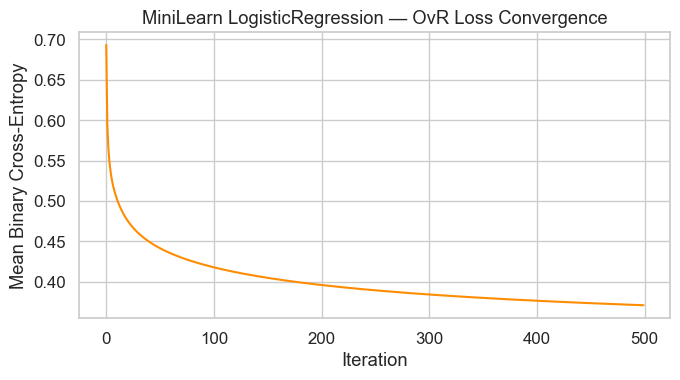

In [15]:
from SER_Project.minilearn.classifiers import LogisticRegression as MLLogReg
from SER_Project.minilearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression as SkLogReg
from sklearn.metrics import accuracy_score as sk_acc, f1_score as sk_f1

# Binary classification: predict intensity label (1 vs 2)
# Use the already-scaled data from the regression section above

ml_logreg = MLLogReg(learning_rate=0.1, n_iterations=500, lambda_=0.01)
ml_logreg.fit(X_train_s, y_train)
y_pred_logreg = ml_logreg.predict(X_test_s)

sk_logreg = SkLogReg(max_iter=1000, C=100)
sk_logreg.fit(sk_X_train, y_train)
y_pred_sk_logreg = sk_logreg.predict(sk_X_test)

print('=== Logistic Regression Preview: Binary Intensity Classification ===')
print(f'  MiniLearn LR — Accuracy: {accuracy_score(y_test, y_pred_logreg):.4f}  '
      f'F1 (macro): {f1_score(y_test, y_pred_logreg):.4f}')
print(f'  Sklearn   LR — Accuracy: {sk_acc(y_test, y_pred_sk_logreg):.4f}  '
      f'F1 (macro): {sk_f1(y_test, y_pred_sk_logreg, average="macro"):.4f}')

# Convergence plot
plt.figure(figsize=(7, 4))
plt.plot(ml_logreg.loss_history_, color='darkorange')
plt.xlabel('Iteration')
plt.ylabel('Mean Binary Cross-Entropy')
plt.title('MiniLearn LogisticRegression — OvR Loss Convergence')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/w6_logreg_convergence.png', dpi=120)
plt.show()

## 12. Discussion & Key Findings

### Regression Analysis

Model performance. All linear regression variants (OLS, Ridge, Lasso) achieve similar R² on the test set. Values above zero confirm that audio features carry meaningful information about vocal intensity, though predicting a binary label with a continuous model limits overall performance.

Normal equation vs. gradient descent. Both solvers produce nearly identical results on this dataset. The normal equation is faster for ~1,440 samples and 192 features; gradient descent is preferred at larger scale.

Feature interpretation. RMS energy and spectral bandwidth have the largest positive coefficients, consistent with strong-intensity speech being louder and spectrally broader. MFCC coefficients also contribute, reflecting vocal tract changes under higher effort.

Residual structure. The bimodal residual pattern reflects the binary target. Logistic Regression (Section 11) is the more appropriate tool and outperforms regression at assigning the binary intensity label.

### MiniLearn Library

MSE, MAE, and R² match sklearn to machine precision. StandardScaler parameters are identical. The implementation is validated and ready for the classifiers built in Week 7.

### Next Steps (Week 7)
- Apply MiniLearn LogisticRegression to the full 8-class emotion task.
- Implement GaussianNaiveBayes and KNN.
- Begin systematic hyperparameter search.